In [97]:
import numpy as np
import pandas as pd
from sklearn import linear_model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [31]:
data = pd.read_csv('datasets\salary.csv')
df = pd.DataFrame(data)

In [32]:
df.head()

,experience,test_score,salary
0,3,80,76100
1,5,84,85600
2,6,74,82000
3,8,85,107200
4,2,73,69700


In [73]:
df.corr()

,experience,test_score,salary
experience,1.000000,-0.006443,0.905728
test_score,-0.006443,1.000000,0.165184
salary,0.905728,0.165184,1.000000


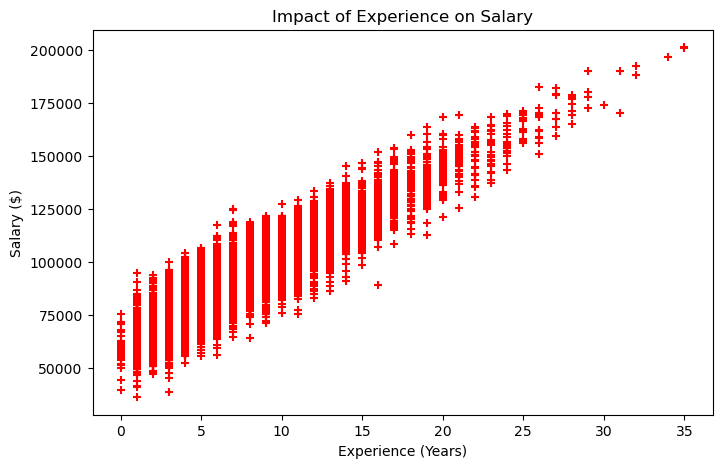

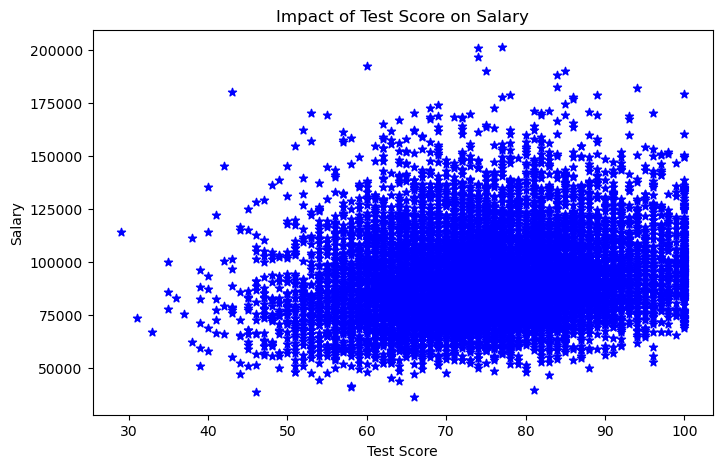

In [110]:
# 1. Experience vs Salary
plt.figure(figsize=(8, 5))
plt.scatter(df['experience'], df['salary'], color='red', marker='+')
plt.xlabel("Experience (Years)")
plt.ylabel("Salary ($)")
plt.title("Impact of Experience on Salary")
plt.savefig('experience_vs_salary.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Test Score vs Salary
plt.figure(figsize=(8, 5))
plt.scatter(df['test_score'], df['salary'], color='blue', marker='*')
plt.xlabel("Test Score")
plt.ylabel("Salary")
plt.title("Impact of Test Score on Salary")
plt.savefig('testscore_vs_salary.png', dpi=300, bbox_inches='tight')
plt.show()

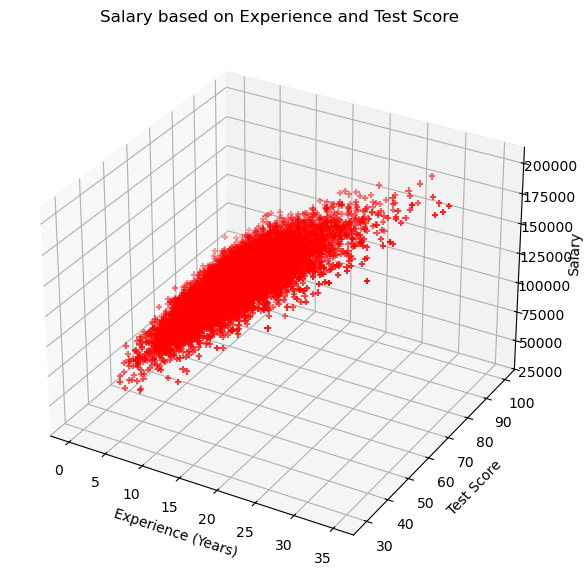

In [111]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Assign axes: X=Experience, Y=Test Score, Z=Salary
x_data = df['experience']
y_data = df['test_score']
z_data = df['salary']

ax.scatter(x_data, y_data, z_data, color='red', marker='+')

ax.set_xlabel('Experience (Years)')
ax.set_ylabel('Test Score')
ax.set_zlabel('Salary')
ax.set_title('Salary based on Experience and Test Score')

plt.savefig('3d_plot_of_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

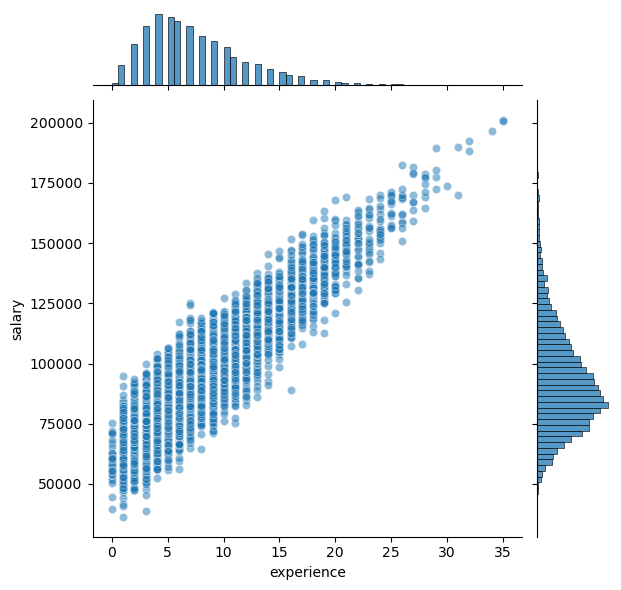

In [115]:
sns.jointplot(x="experience", y="salary", data=df, alpha=0.5)
plt.savefig('experience-Salary_seaborn_plot_scatter_bar.png', dpi=300, bbox_inches='tight')

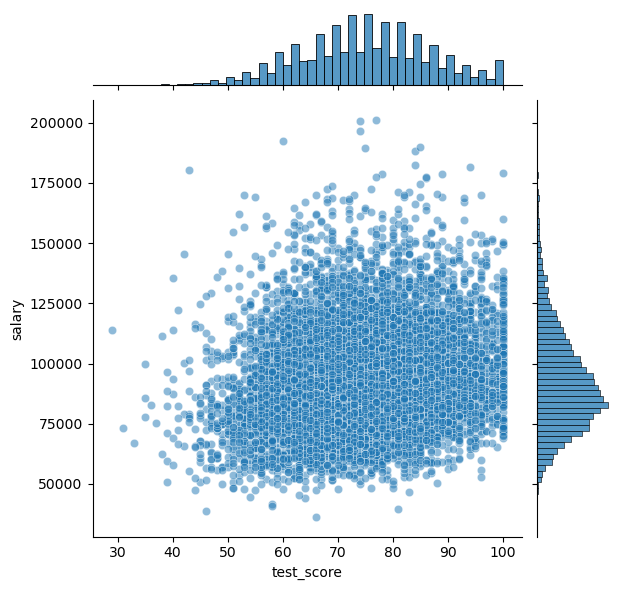

In [116]:
sns.jointplot(x="test_score", y="salary", data=df, alpha=0.5)
plt.savefig('testScore-Salary_seaborn_plot_scatter_bar.png', dpi=300, bbox_inches='tight')

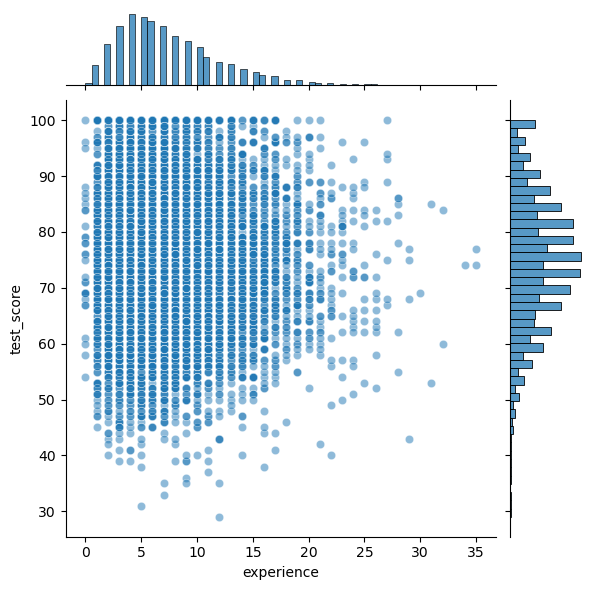

In [117]:
sns.jointplot(x="experience", y="test_score", data=df, alpha=0.5)
plt.savefig('Experience-TestScore_seaborn_plot_scatter_bar.png', dpi=300, bbox_inches='tight')

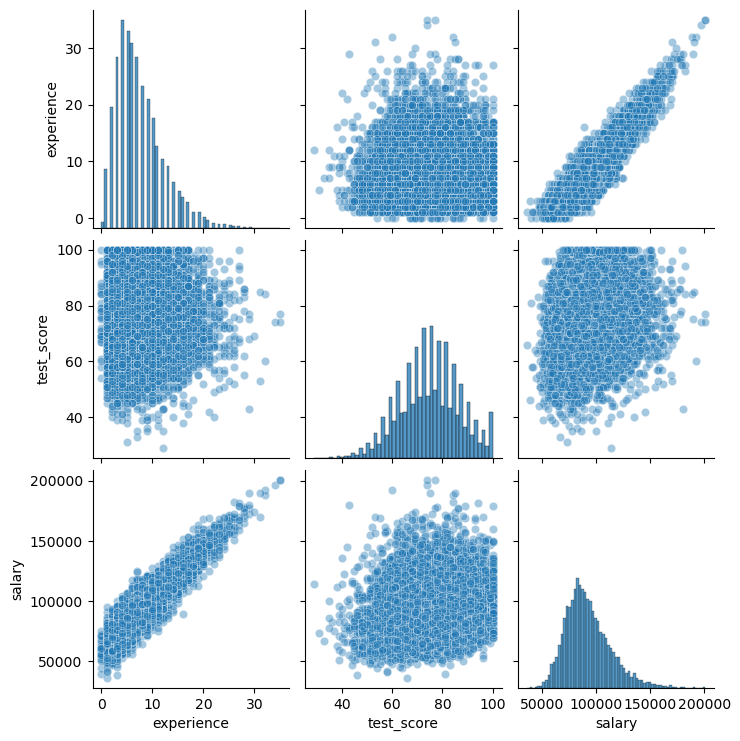

In [118]:
sns.pairplot(df, kind='scatter', plot_kws={'alpha': 0.4})
plt.savefig('seaborn_Allplot.png', dpi=300, bbox_inches='tight')

In [91]:
X_single = df[['experience']]
X_multi = df[['experience', 'test_score']]

In [92]:
from sklearn.model_selection import train_test_split
X_s_train, X_s_test, y_train, y_test = train_test_split(X_single, y, test_size=0.2, random_state=42)
X_m_train, X_m_test, _, _ = train_test_split(X_multi, y, test_size=0.2, random_state=42)

In [93]:
# 3. Train Models
# Train Single Feature Model
model_single = LinearRegression()
model_single.fit(X_s_train, y_train)
y_pred_single = model_single.predict(X_s_test)

In [94]:
# Train Multiple Feature Model
model_multi = LinearRegression()
model_multi.fit(X_m_train, y_train)
y_pred_multi = model_multi.predict(X_m_test)

In [106]:
# 4. Evaluate Models
# Calculate RMSE (Root Mean Squared Error) and R2 (Coefficient of Determination)
rmse_single = np.sqrt(mean_squared_error(y_test, y_pred_single))
r2_single = r2_score(y_test, y_pred_single)

rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)

print("Single Feature Model (Experience only):")
print(f"  RMSE: {rmse_single:,.2f} | R²: {r2_single:.4f}")

print("\nMultiple Feature Model (Experience + Test Score):")
print(f"  RMSE: {rmse_multi:,.2f} | R²: {r2_multi:.4f}")

Single Feature Model (Experience only):
  RMSE: 8,559.60 | R²: 0.8306

Multiple Feature Model (Experience + Test Score):
  RMSE: 7,736.52 | R²: 0.8616


In [107]:
# 5. Compare and Save Best Model
if r2_multi > r2_single:
    best_model = model_multi
    print("\nSaving Multiple Feature Model...")
else:
    best_model = model_single
    print("\nSaving Single Feature Model...")

# Save the chosen model to disk for future predictions
joblib.dump(best_model, 'best_salary_model.pkl')


Saving Multiple Feature Model...


['best_salary_model.pkl']

In [ ]:
# Load the model
loaded_model = joblib.load('best_salary_model.pkl')
year = int(input("Enter Experience: "))
score = int(input("Enter Test Score: "))
if ((year < 50) & (score <=100)):
    # Make a prediction (e.g., 5 years experience, 85 test score)
    new_candidate = pd.DataFrame({'experience': [year], 'test_score': [score]})
    predicted_salary = loaded_model.predict(new_candidate)
    
    print(f"Predicted Salary: {predicted_salary[0]:,.2f}")
else:
    print("Invalid input! Please ensure Experience is 0-50 and Test Score is 0-100.")